In [59]:
import numpy as np
import pandas as pd
train = pd.read_csv(r'C:\Users\fuhre\Desktop\data\train.csv', decimal=',', sep=';')
test = pd.read_csv(r'C:\Users\fuhre\Desktop\data\test.csv', decimal=',', sep=';')

C:\Users\fuhre\AppData\Local\Temp\ipykernel_36000\2748689485.py:3: DtypeWarning: Columns (66) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(r'C:\Users\fuhre\Desktop\data\train.csv', decimal=',', sep=';')
C:\Users\fuhre\AppData\Local\Temp\ipykernel_36000\2748689485.py:4: DtypeWarning: Columns (65) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv(r'C:\Users\fuhre\Desktop\data\test.csv', decimal=',', sep=';')


In [60]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (76786, 224)
Test shape: (73214, 222)


In [61]:
train_cols = set(train.columns)
test_cols = set(test.columns)
print(f"Колонки только в Train ({len(sorted(train_cols - test_cols))}):")
print(sorted(train_cols - test_cols))
print(f"Колонки только в Test ({len(sorted(test_cols - train_cols))}):")
print(sorted(test_cols - train_cols))

Колонки только в Train (2):
['target', 'w']
Колонки только в Test (0):
[]


ТЕРГЕТ. Распеределение.

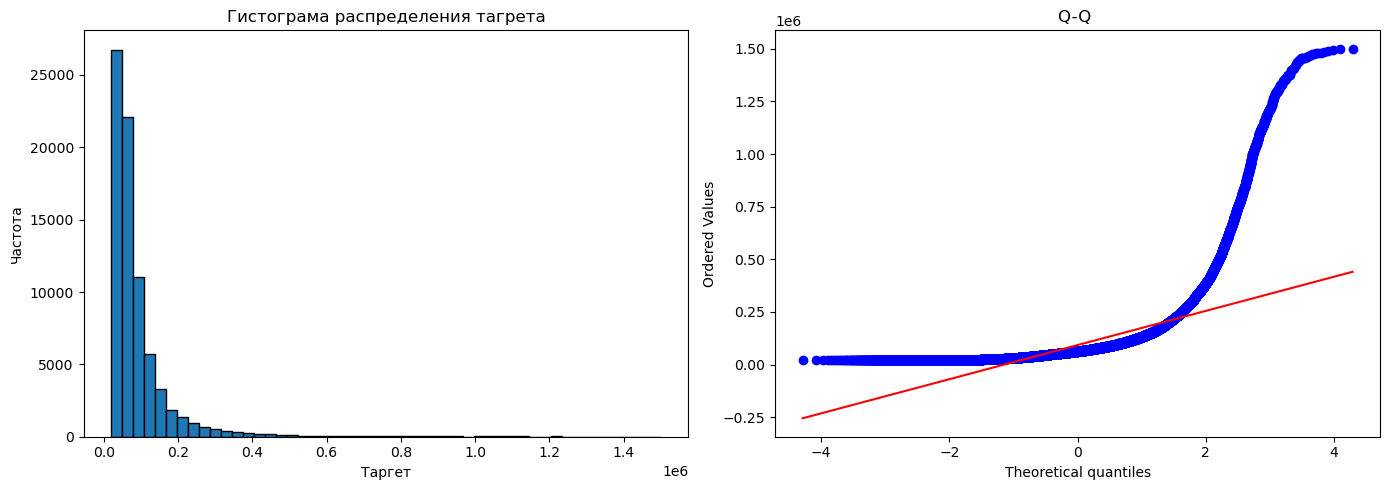

In [24]:
import matplotlib.pyplot as plt
from scipy import stats
y = train["target"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y, bins=50, edgecolor="black")
axes[0].set_title("Гистограма распределения тагрета")
axes[0].set_xlabel("Таргет")
axes[0].set_ylabel("Частота")
stats.probplot(y, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q ")
plt.tight_layout()
plt.show()

Таргет имеют сильно скошенное распределение с длинным правым хвостом. Q-Q plot показывает отклонение от нормальности. 

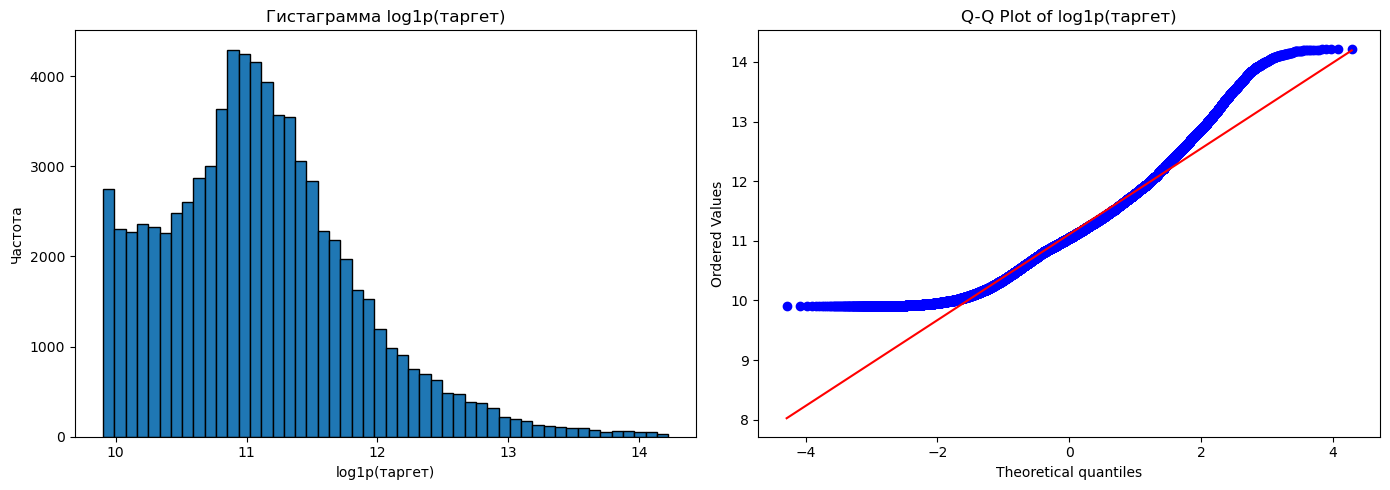

In [31]:
# логарифмирование тагрета
train["log_target"] = np.log1p(train["target"])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(train["log_target"], bins=50, edgecolor="black")
axes[0].set_title("Гистаграмма log1p(таргет)")
axes[0].set_xlabel("log1p(таргет)")
axes[0].set_ylabel("Частота")
stats.probplot(train["log_target"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of log1p(таргет)")
plt.tight_layout()
plt.show()

При логарифмировании распределение становится более нормальным и становится ближе к линии нормальности на Q-Q plot.

In [10]:
# Вывод -- тагрет в работе лучше логарифмировать. Окей гений

Определение процентилей.

In [3]:
train["target"].describe(percentiles=[0.001, 0.01, 0.05, 0.95, 0.99, 0.999])

count    7.678600e+04
mean     9.264824e+04
std      1.124090e+05
min      2.000000e+04
0.1%     2.001000e+04
1%       2.040658e+04
5%       2.271157e+04
50%      6.275413e+04
95%      2.560746e+05
99%      5.965851e+05
99.9%    1.291317e+06
max      1.500000e+06
Name: target, dtype: float64

In [4]:
low_salary = train[train["target"] <= 1]
print(f"Количество объектов с зарплатой <= 1: {len(low_salary)}")
display(low_salary)

Количество объектов с зарплатой <= 1: 0


,id,dt,target,turn_cur_cr_avg_act_v2,salary_6to12m_avg,hdb_bki_total_max_limit,dp_ils_paymentssum_avg_12m,hdb_bki_total_cc_max_limit,incomeValue,gender,...,dp_ils_uniq_companies_1y,avg_6m_travel,avg_6m_government_services,hdb_bki_active_cc_max_overdue,total_rur_amt_cm_avg_period_days_ago_v2,label_Above_1M_share_r1,transaction_category_supermarket_sum_cnt_d15,max_balance_rur_amt_1m_af,w,first_salary_income


In [5]:
Q1 = train["target"].quantile(0.25)
Q3 = train["target"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
high_salary = train[train["target"] > upper_bound]
print(f"Граница выбросов: {upper_bound:,.0f}")
print(f"Количество выбросов: {len(high_salary)}")
display(high_salary.sort_values("target", ascending=False))

Граница выбросов: 190,939
Количество выбросов: 6434


,id,dt,target,turn_cur_cr_avg_act_v2,salary_6to12m_avg,hdb_bki_total_max_limit,dp_ils_paymentssum_avg_12m,hdb_bki_total_cc_max_limit,incomeValue,gender,...,dp_ils_uniq_companies_1y,avg_6m_travel,avg_6m_government_services,hdb_bki_active_cc_max_overdue,total_rur_amt_cm_avg_period_days_ago_v2,label_Above_1M_share_r1,transaction_category_supermarket_sum_cnt_d15,max_balance_rur_amt_1m_af,w,first_salary_income
27285,53313,2024-03-31,1.500000e+06,1.576649e+07,NaN,4405400.0,1.055313e+05,200000.0,238443.0,Мужской,...,1.0,0.0,42.0,0.0,56649.0,0.000000,47.0,NaN,2.570703,NaN
61571,120563,2024-04-30,1.500000e+06,4.649183e+07,1.533111e+06,36508744.0,2.612932e+06,3000000.0,208547.0,Мужской,...,6.0,5290.0,833.0,0.0,1732880.0,NaN,NaN,553398.0,2.570703,1.526007e+06
23366,45760,2024-01-31,1.494204e+06,3.086897e+07,1.527583e+06,2479500.0,NaN,1500000.0,230372.0,Мужской,...,NaN,25100.0,833.0,0.0,693304.0,0.113636,8.0,19665596.0,2.570703,1.569751e+06
28581,55813,2024-03-31,1.489903e+06,1.167751e+07,NaN,11227447.0,3.117802e+06,1500000.0,355871.0,Женский,...,1.0,0.0,3897.0,0.0,11708306.0,0.107143,4.0,NaN,2.570703,NaN
48643,94961,2024-03-31,1.486000e+06,1.145187e+07,5.685887e+05,4251000.0,5.890437e+05,2000000.0,38346.0,Мужской,...,3.0,0.0,354.0,0.0,2978.0,NaN,NaN,NaN,2.570703,1.631707e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9036,17571,2024-05-31,1.910000e+05,1.346370e+07,2.533454e+05,13500000.0,NaN,0.0,147727.0,Женский,...,NaN,0.0,0.0,0.0,6889.0,NaN,NaN,NaN,1.273347,3.113389e+05
49570,96849,2024-06-30,1.909828e+05,NaN,NaN,1210608.5,NaN,400000.0,115903.0,Женский,...,NaN,0.0,0.0,16679.94,0.0,NaN,NaN,NaN,1.273143,NaN
48724,95129,2024-04-30,1.909791e+05,7.798550e+05,NaN,949500.0,NaN,802000.0,159637.0,Мужской,...,NaN,0.0,4149.0,0.0,279106.0,0.000000,3.0,NaN,1.273099,NaN
43581,85125,2024-05-31,1.909436e+05,NaN,NaN,845000.0,NaN,230000.0,NaN,Женский,...,NaN,NaN,NaN,3371.86,0.0,NaN,NaN,NaN,1.272676,NaN


In [29]:
# train.nlargest(20, "target")

In [7]:
p999 = train["target"].quantile(0.999)
extreme_salary = train[train["target"] >= p999]
print(f"99.9-й процентиль: {p999:,.0f}")
display(extreme_salary.sort_values("target", ascending=False))

99.9-й процентиль: 1,291,317


,id,dt,target,turn_cur_cr_avg_act_v2,salary_6to12m_avg,hdb_bki_total_max_limit,dp_ils_paymentssum_avg_12m,hdb_bki_total_cc_max_limit,incomeValue,gender,...,dp_ils_uniq_companies_1y,avg_6m_travel,avg_6m_government_services,hdb_bki_active_cc_max_overdue,total_rur_amt_cm_avg_period_days_ago_v2,label_Above_1M_share_r1,transaction_category_supermarket_sum_cnt_d15,max_balance_rur_amt_1m_af,w,first_salary_income
61571,120563,2024-04-30,1.500000e+06,4.649183e+07,1.533111e+06,36508744.0,2.612932e+06,3000000.0,208547.0,Мужской,...,6.0,5290.0,833.0,0.0,1732880.0,NaN,NaN,553398.0,2.570703,1.526007e+06
27285,53313,2024-03-31,1.500000e+06,1.576649e+07,NaN,4405400.0,1.055313e+05,200000.0,238443.0,Мужской,...,1.0,0.0,42.0,0.0,56649.0,0.000000,47.0,NaN,2.570703,NaN
23366,45760,2024-01-31,1.494204e+06,3.086897e+07,1.527583e+06,2479500.0,NaN,1500000.0,230372.0,Мужской,...,NaN,25100.0,833.0,0.0,693304.0,0.113636,8.0,19665596.0,2.570703,1.569751e+06
28581,55813,2024-03-31,1.489903e+06,1.167751e+07,NaN,11227447.0,3.117802e+06,1500000.0,355871.0,Женский,...,1.0,0.0,3897.0,0.0,11708306.0,0.107143,4.0,NaN,2.570703,NaN
48643,94961,2024-03-31,1.486000e+06,1.145187e+07,5.685887e+05,4251000.0,5.890437e+05,2000000.0,38346.0,Мужской,...,3.0,0.0,354.0,0.0,2978.0,NaN,NaN,NaN,2.570703,1.631707e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73704,144110,2024-06-30,1.294761e+06,1.509659e+07,NaN,21666300.0,3.023514e+06,2700000.0,174378.0,Мужской,...,1.0,72695.0,1064.0,0.0,7368762.0,0.018519,11.0,NaN,2.570703,NaN
50729,99198,2024-04-30,1.293241e+06,2.284706e+07,1.806883e+06,11382507.0,NaN,425000.0,246217.0,Мужской,...,NaN,45827.0,0.0,NaN,223125.0,0.037037,9.0,23759.0,2.570703,1.402507e+06
15492,30347,2024-04-30,1.293090e+06,6.497475e+06,NaN,0.0,NaN,0.0,63852.0,Мужской,...,NaN,0.0,0.0,NaN,244642.0,NaN,NaN,NaN,2.570703,NaN
50842,99432,2024-04-30,1.293000e+06,6.309413e+06,NaN,31530800.0,NaN,600000.0,42323.0,Мужской,...,NaN,NaN,NaN,NaN,2001.0,NaN,NaN,NaN,2.570703,NaN


In [32]:
print(f"Минимальное значение: {train['target'].min():,.0f}")
print(f"Максимальное значение: {train['target'].max():,.0f}")
print(f"Количество тагрет = 0: {(train['target'] == 0).sum()}")
print(f"Количество тагргет = 1: {(train['target'] == 1).sum()}")
print(f"Количество таргет > 99.9 перцентиля: {(train['target'] >= train['target'].quantile(0.999)).sum()}")

Минимальное значение: 20,000
Максимальное значение: 1,500,000
Количество тагрет = 0: 0
Количество тагргет = 1: 0
Количество таргет > 99.9 перцентиля: 77


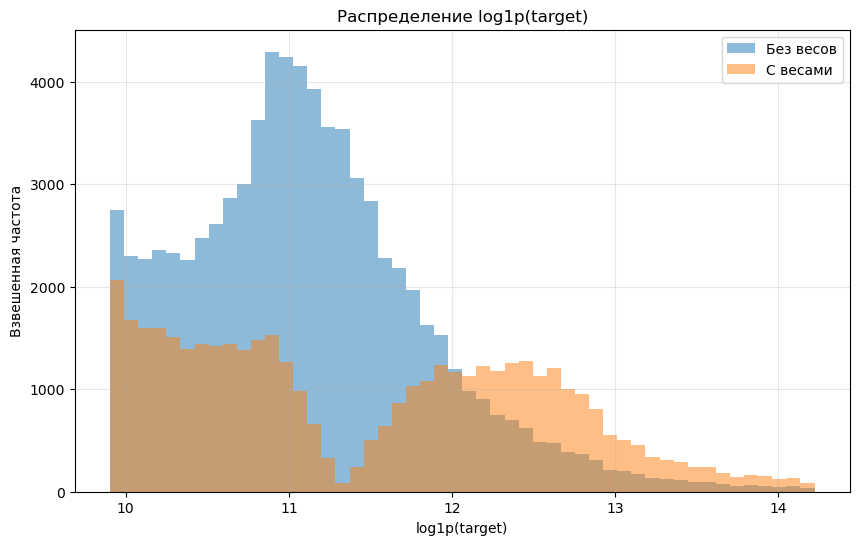

In [11]:
# как веса изменяют вклад объектов в различных диапазонах
plt.figure(figsize=(10, 6))
log_target = np.log1p(train["target"])
plt.hist(log_target, bins=50, alpha=0.5, label="Без весов")
plt.hist(log_target, bins=50, weights=train["w"], alpha=0.5, label="С весами")
plt.xlabel("log1p(target)")
plt.ylabel("Взвешенная частота")
plt.title("Распределение log1p(target)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

count    76786.000000
mean         0.569014
std          0.551835
min          0.000021
25%          0.235950
50%          0.449424
75%          0.680337
max          2.570703
Name: w, dtype: float64


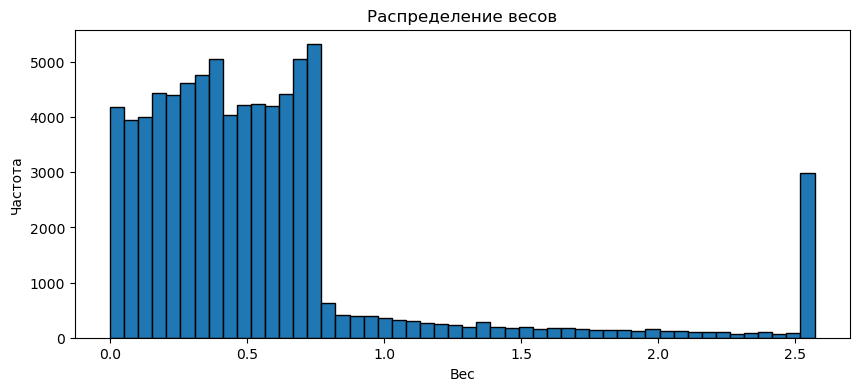

In [25]:
print(train['w'].describe())
plt.figure(figsize=(10, 4))
plt.hist(train['w'], bins=50, edgecolor='black')
plt.title('Распределение весов')
plt.xlabel('Вес')
plt.ylabel('Частота')
plt.show()

Веса не равномерны – некоторые объекты имеют в 2-3 раза больший вес. Дальше в работе веса будут передаваться в sample_weight при обучении и использоваться при расчёте WMAE.

Корреляция с таргетом

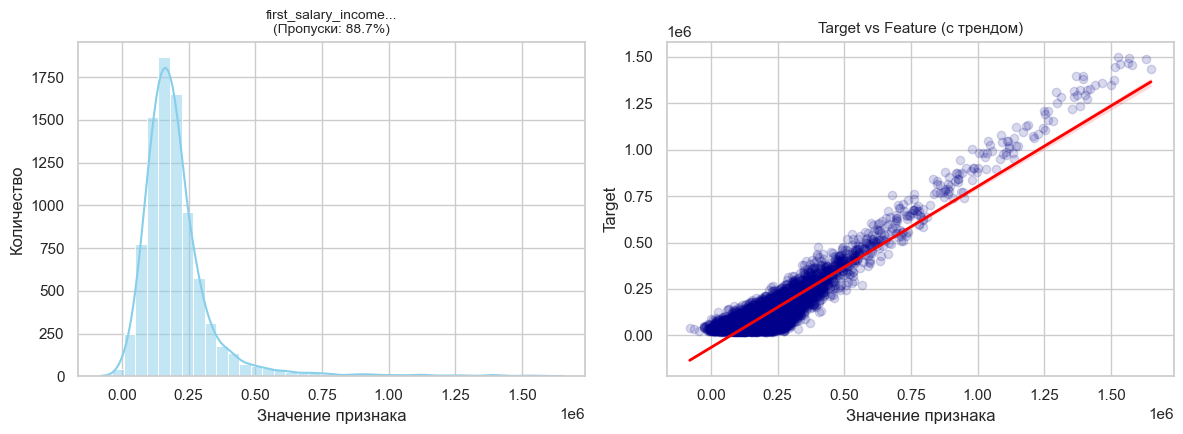

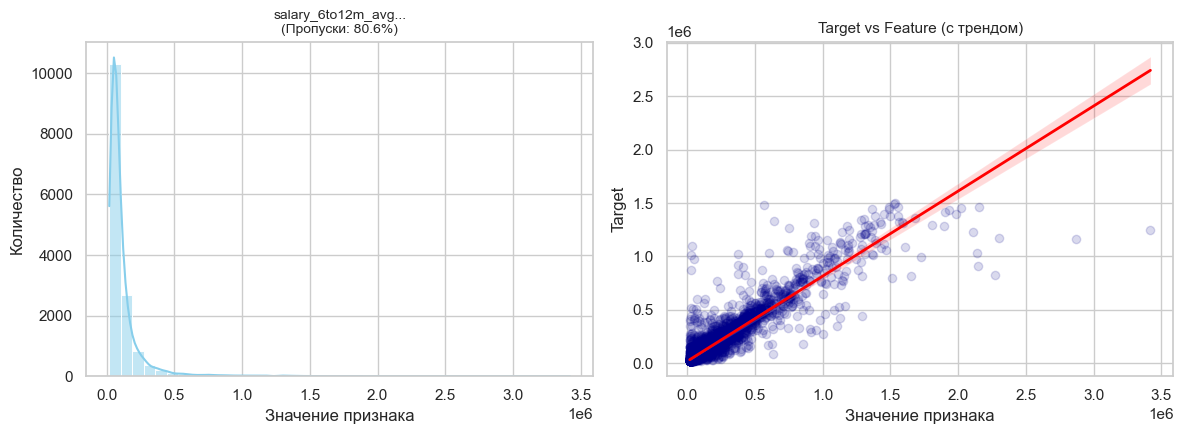

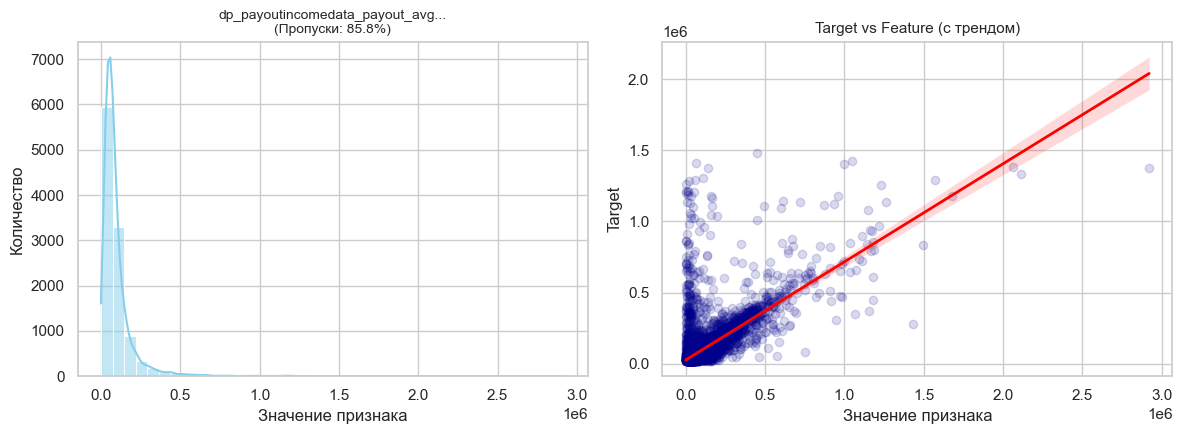

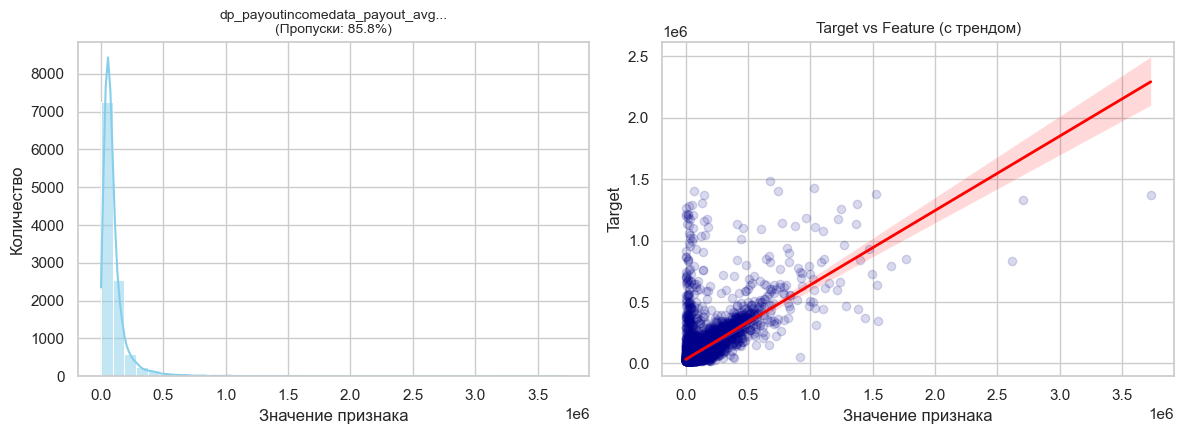

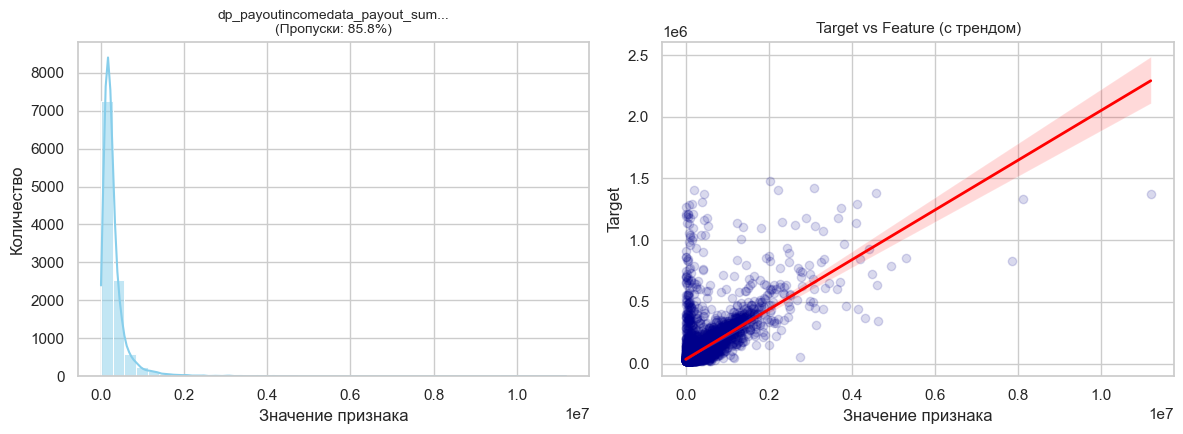

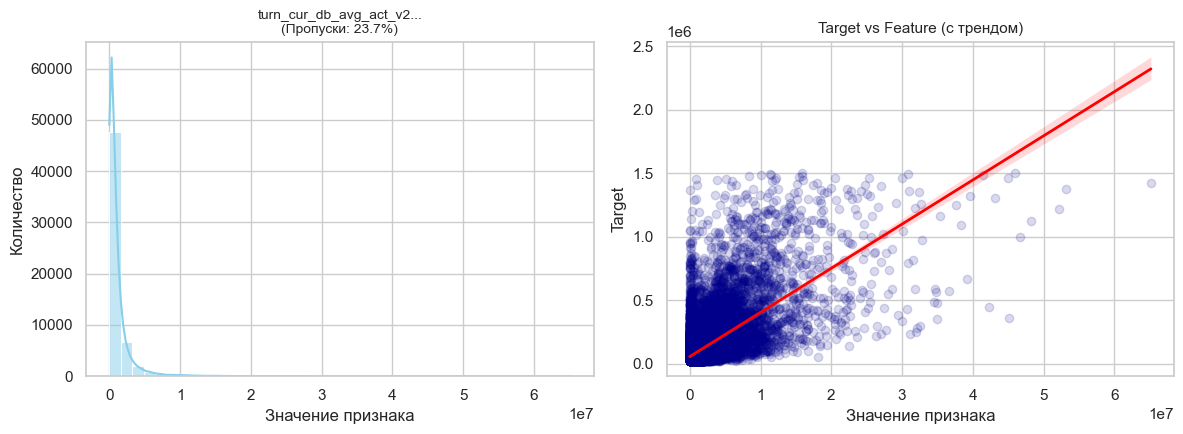

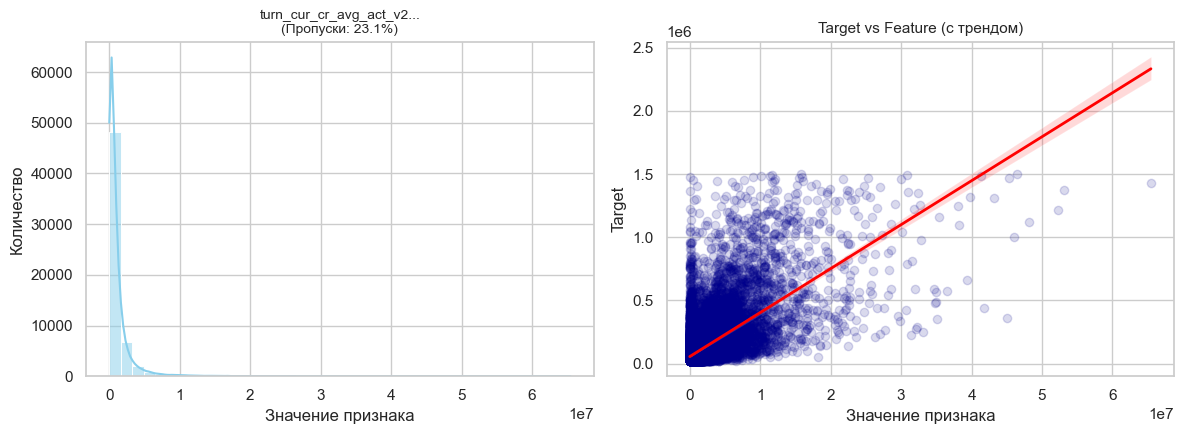

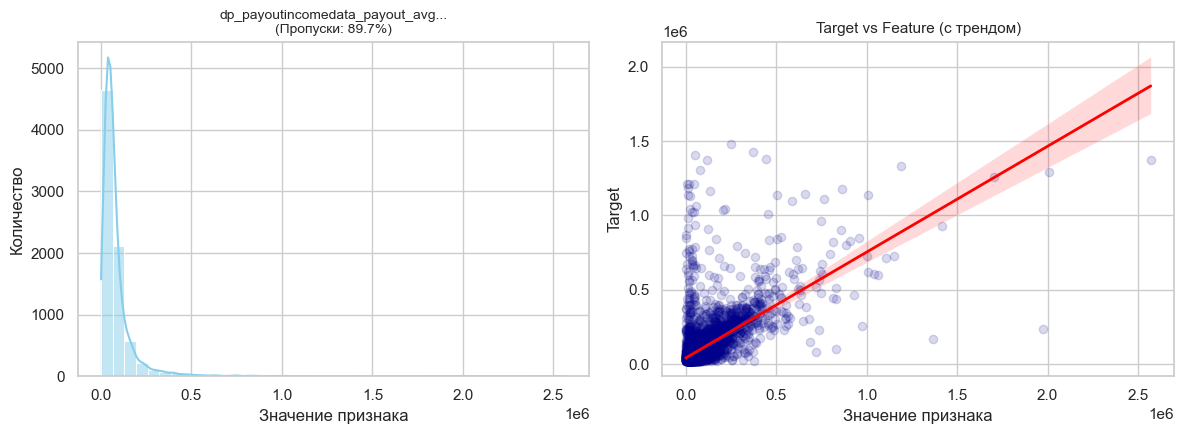

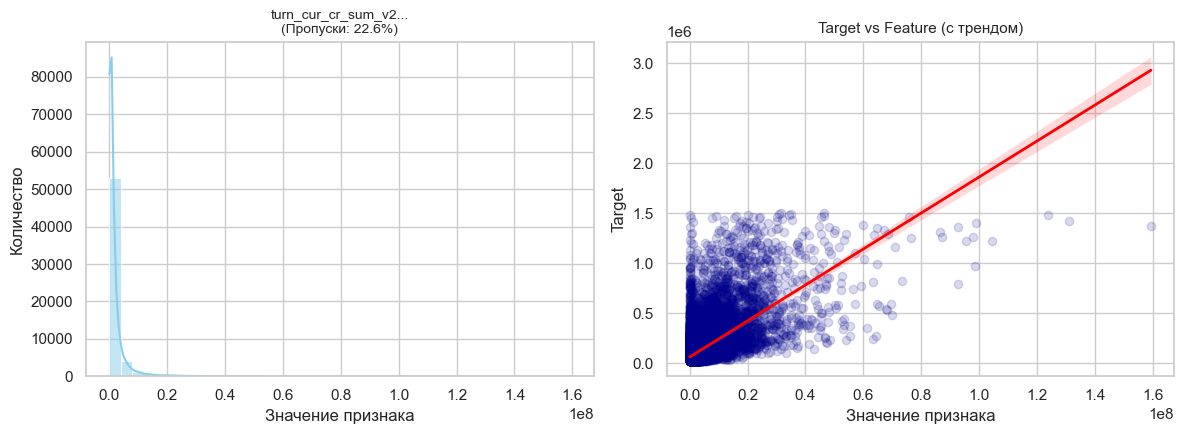

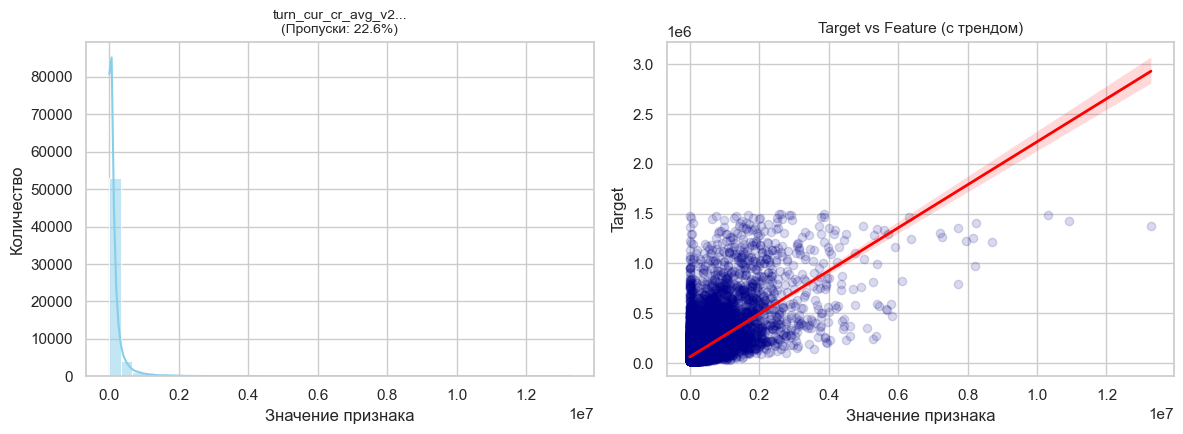

In [51]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

for col in corr_target.head(10).index:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    clean_data = train[col].dropna()
    
    sns.histplot(clean_data, bins=40, kde=True, ax=axes[0], color='skyblue')
    missing_pct = train[col].isna().mean() * 100
    axes[0].set_title(f"{col[:30]}...\n(Пропуски: {missing_pct:.1f}%)", fontsize=10)
    axes[0].set_xlabel("Значение признака")
    axes[0].set_ylabel("Количество")

    scatter_df = train[[col, 'target']].dropna()
    sns.regplot(data=scatter_df, x=col, y="target", ax=axes[1], scatter_kws={'alpha': 0.15, 'color': 'darkblue'},line_kws={'color': 'red', 'linewidth': 2})
    
    axes[1].set_title("Target vs Feature (с трендом)", fontsize=11)
    axes[1].set_xlabel("Значение признака")
    axes[1].set_ylabel("Target")

    plt.tight_layout()
    plt.show()


In [33]:
numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["target", "log_target", "w"]]
corr_target = (
    train[numeric_cols + ["target"]]
    .corr()["target"]
    .drop("target")
    .sort_values(key=np.abs, ascending=False)
)
display(corr_target.head(20))

first_salary_income                         0.928217
salary_6to12m_avg                           0.927699
dp_payoutincomedata_payout_avg_6_month      0.672173
dp_payoutincomedata_payout_avg_3_month      0.644840
dp_payoutincomedata_payout_sum_3_month      0.644542
turn_cur_db_avg_act_v2                      0.640399
turn_cur_cr_avg_act_v2                      0.638592
dp_payoutincomedata_payout_avg_prev_year    0.630530
turn_cur_cr_sum_v2                          0.630285
turn_cur_cr_avg_v2                          0.630285
turn_cur_db_sum_v2                          0.628880
turn_cur_db_avg_v2                          0.628880
dp_ils_paymentssum_avg_12m                  0.613925
dp_ils_paymentssum_avg_6m_current           0.594897
dp_ils_paymentssum_avg_6m                   0.594784
avg_6m_all                                  0.570469
dp_payoutincomedata_payout_max_6_month      0.564312
dp_payoutincomedata_payout_max_3_month      0.561221
dp_ils_paymentssum_month_avg                0.

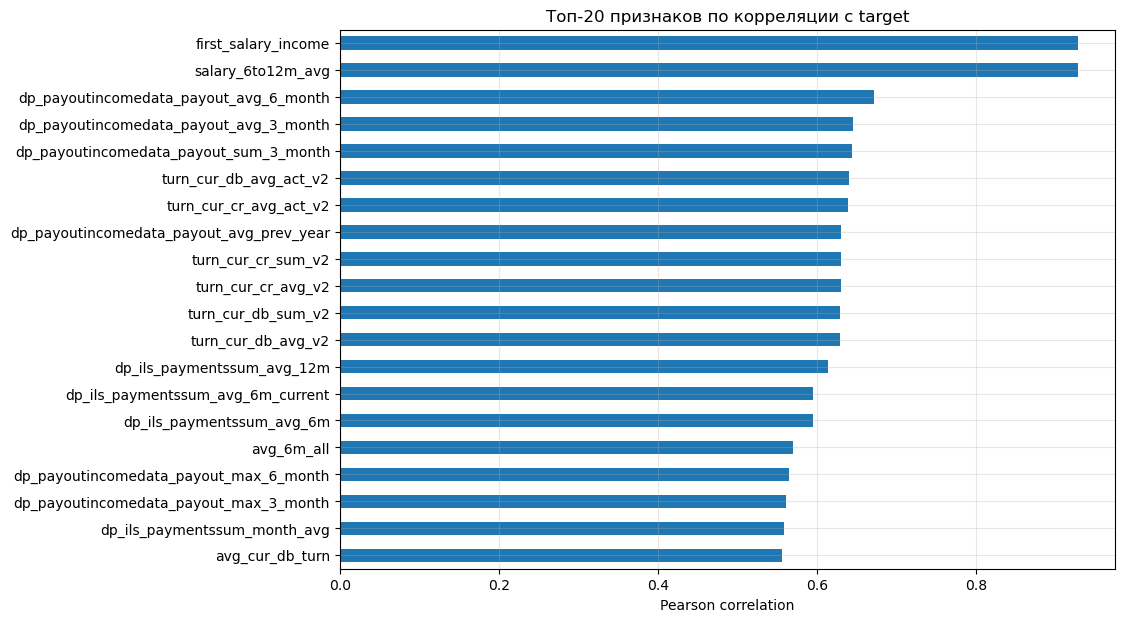

In [34]:
top20 = corr_target.head(20)
plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind="barh")
plt.xlabel("Pearson correlation")
plt.title("Топ-20 признаков по корреляции с target")
plt.grid(alpha=0.3)
plt.show()

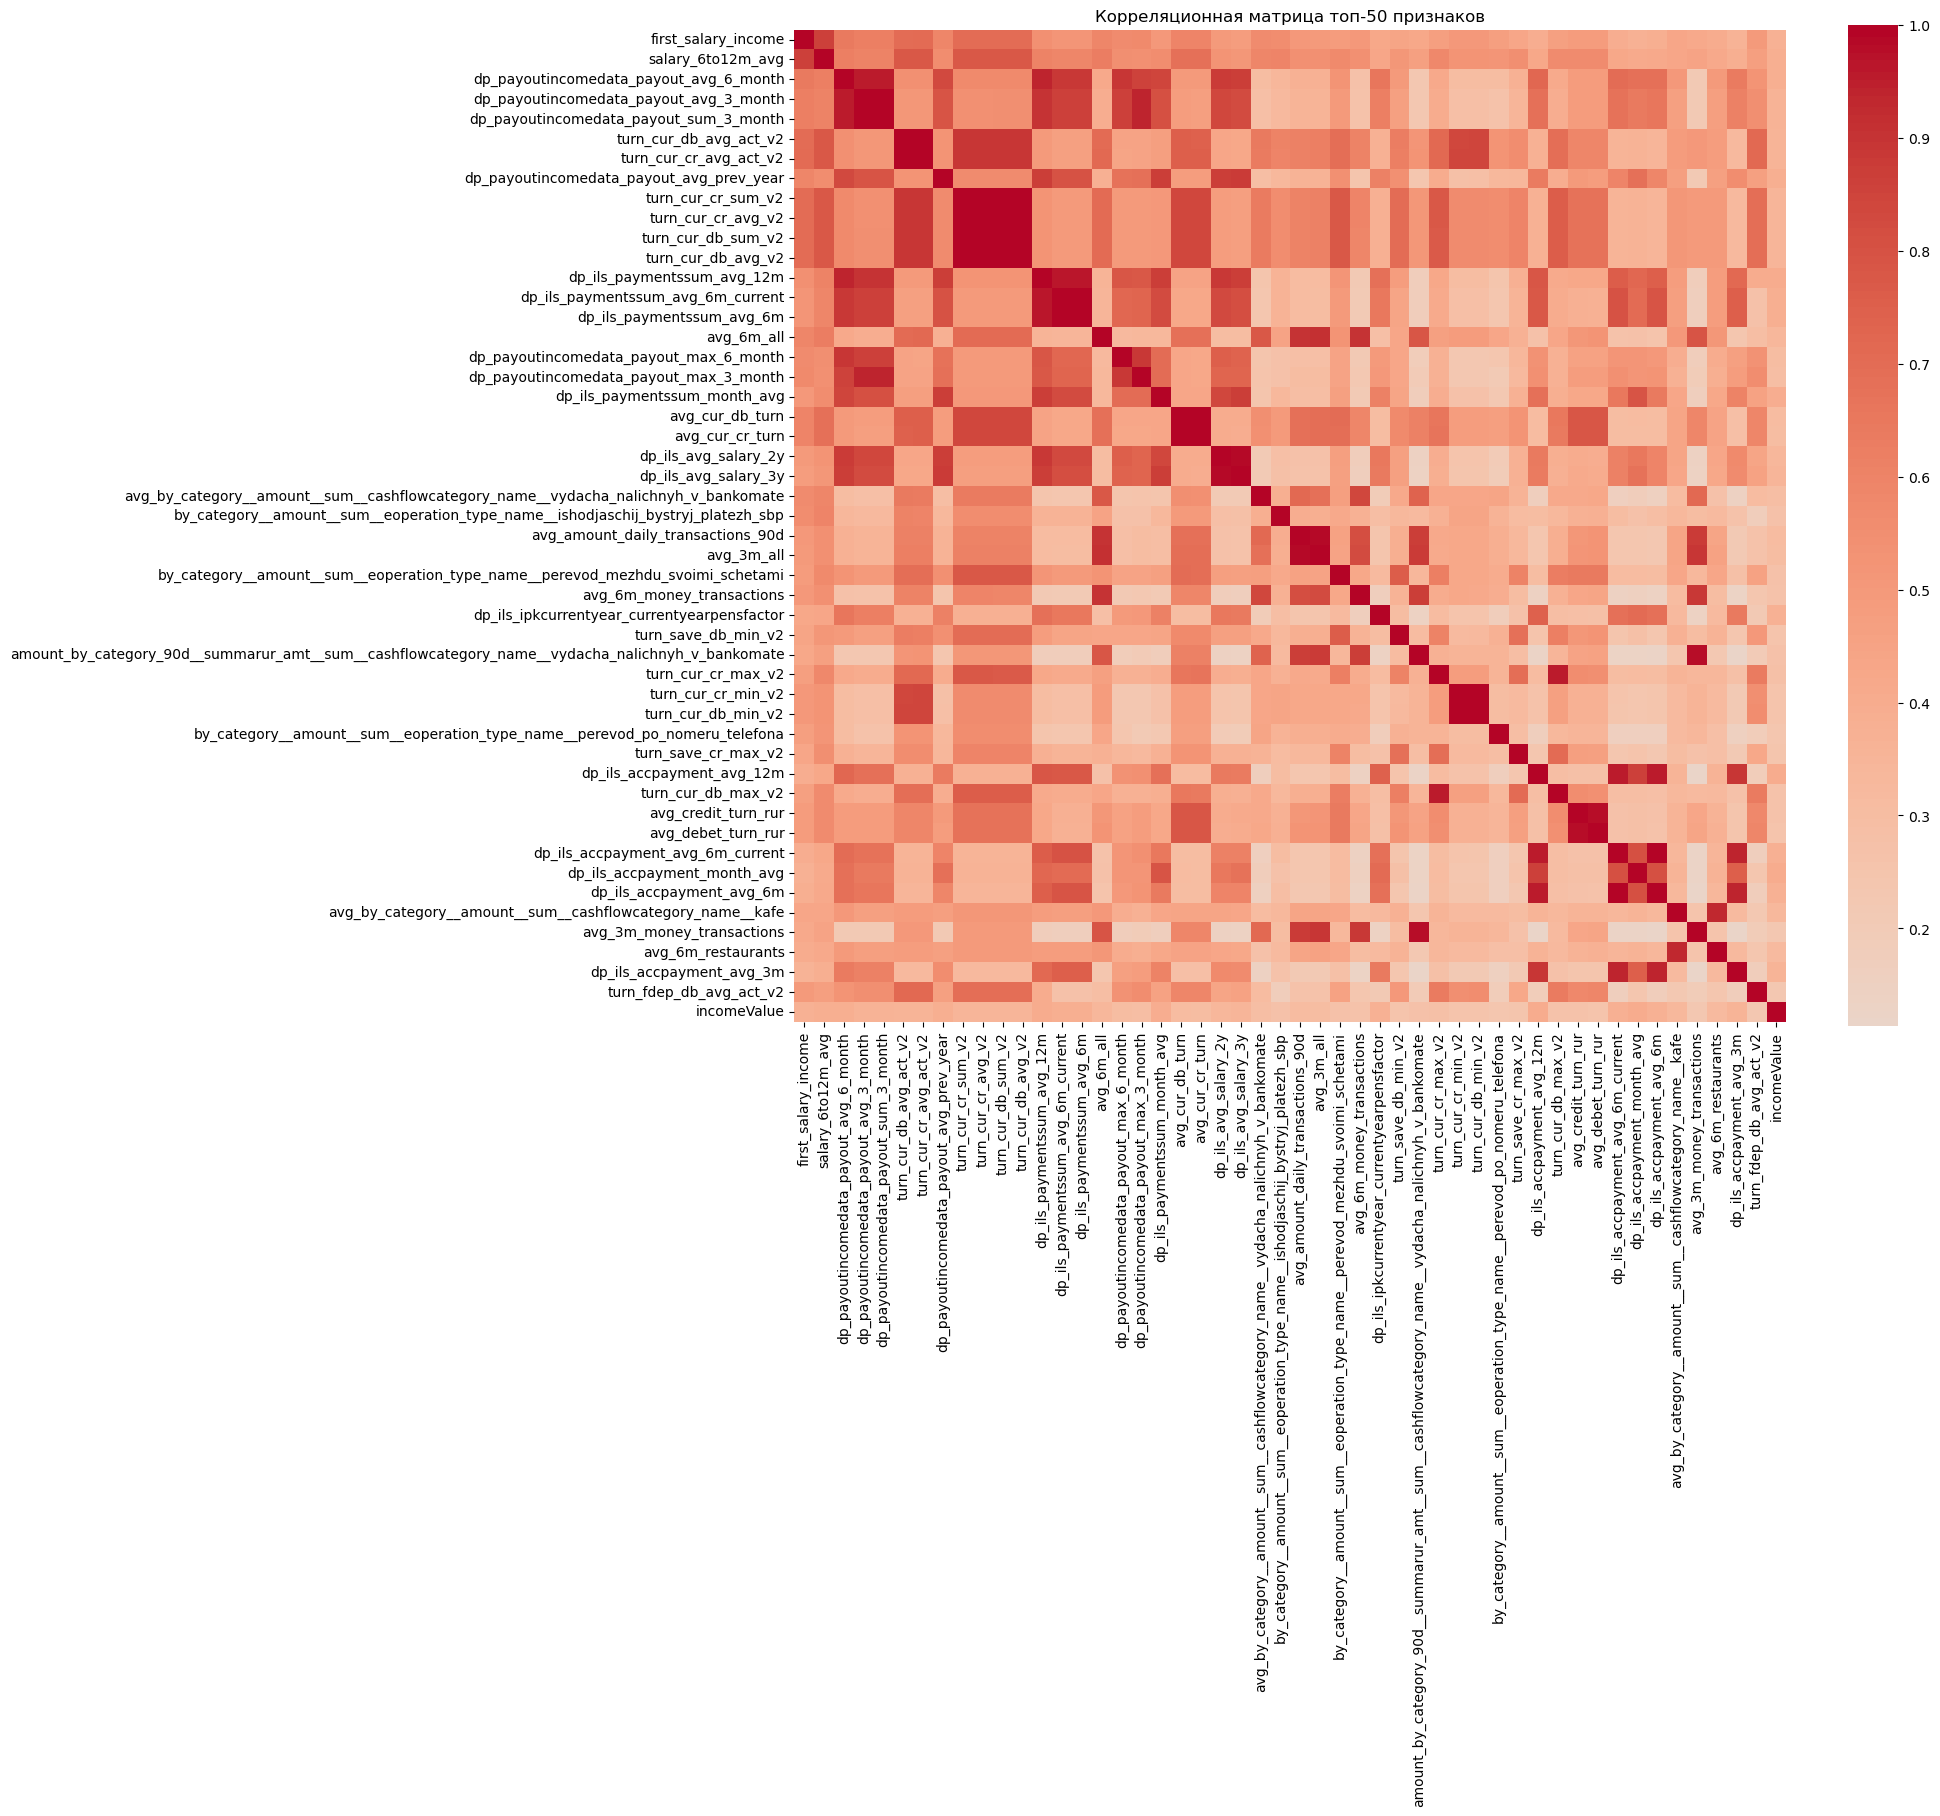

In [36]:
top50 = corr_target.head(50).index.tolist()
import seaborn as sns
corr_matrix = train[top50].corr()
plt.figure(figsize=(16, 13))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True)
plt.title("Корреляционная матрица топ-50 признаков")
plt.show()

In [39]:
corr = train[top50].corr().abs()
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)
high_corr = (upper.stack().reset_index())
high_corr.columns = ["Признак 1", "Признак 2","Корреляция"]
high_corr = high_corr[high_corr["Корреляция"] > 0.9].sort_values("Корреляция",ascending=False)
display(high_corr)

,Признак 1,Признак 2,Корреляция
364,turn_cur_cr_sum_v2,turn_cur_cr_avg_v2,1.000000
445,turn_cur_db_sum_v2,turn_cur_db_avg_v2,1.000000
559,dp_ils_paymentssum_avg_6m_current,dp_ils_paymentssum_avg_6m,0.999962
144,dp_payoutincomedata_payout_avg_3_month,dp_payoutincomedata_payout_sum_3_month,0.999879
406,turn_cur_cr_avg_v2,turn_cur_db_avg_v2,0.999184
405,turn_cur_cr_avg_v2,turn_cur_db_sum_v2,0.999184
366,turn_cur_cr_sum_v2,turn_cur_db_avg_v2,0.999184
365,turn_cur_cr_sum_v2,turn_cur_db_sum_v2,0.999184
1089,turn_cur_cr_min_v2,turn_cur_db_min_v2,0.997954
1190,dp_ils_accpayment_avg_6m_current,dp_ils_accpayment_avg_6m,0.997551


In [38]:
to_drop = [column
           for column in upper.columns
                if any(upper[column] > 0.9)]
print(f"Количество признаков для потенциального удаления: {len(to_drop)}")
print(to_drop)

Количество признаков для удаления: 22
['dp_payoutincomedata_payout_avg_3_month', 'dp_payoutincomedata_payout_sum_3_month', 'turn_cur_cr_avg_act_v2', 'turn_cur_cr_avg_v2', 'turn_cur_db_sum_v2', 'turn_cur_db_avg_v2', 'dp_ils_paymentssum_avg_12m', 'dp_ils_paymentssum_avg_6m_current', 'dp_ils_paymentssum_avg_6m', 'dp_payoutincomedata_payout_max_3_month', 'avg_cur_cr_turn', 'dp_ils_avg_salary_3y', 'avg_3m_all', 'avg_6m_money_transactions', 'turn_cur_db_min_v2', 'turn_cur_db_max_v2', 'avg_debet_turn_rur', 'dp_ils_accpayment_avg_6m_current', 'dp_ils_accpayment_avg_6m', 'avg_3m_money_transactions', 'avg_6m_restaurants', 'dp_ils_accpayment_avg_3m']


Пропуски данных.

In [28]:
test_null_100 = test.columns[test.isnull().all()].tolist()
print("Столбцы с 100% пропусками в test:", test_null_100)
train_null_100 = train.columns[train.isnull().all()].tolist()
print("Столбцы с 100% пропусками в train:", train_null_100)

Столбцы с 100% пропусками в test: ['first_salary_income']
Столбцы с 100% пропусками в train: []


Следует удалить 'first_salary_income' из обоих выборок. 

In [40]:
missing_share = train.isna().mean().sort_values(ascending=False)
missing_df = (missing_share[missing_share > 0.30].to_frame("missing_share"))
display(missing_df)

,missing_share
avg_by_category__amount__sum__cashflowcategory_name__platezhi_cherez_internet,0.984411
turn_fdep_db_avg_act_v2,0.969721
turn_fdep_db_avg_v2,0.950043
turn_fdep_db_sum_v2,0.950043
avg_by_category__amount__sum__cashflowcategory_name__reklama_v_internete,0.931993
...,...
cntRegionTripsWavg1m,0.323249
cntVoiceOutMob6m,0.323249
lifetimeComp,0.323249
businessTelSubs,0.323249


In [42]:
from scipy.stats import mannwhitneyu
results = []
for col in high_missing:
    present = train.loc[train[col].notna(),"target"]
    missing = train.loc[train[col].isna(),"target"]
    if len(missing) == 0:
        continue
    stat, p = mannwhitneyu(present, missing, alternative="two-sided")
    results.append({"feature": col,"p_value": p, 
                    "mean_present": present.mean(), 
                    "mean_missing": missing.mean()})

results = pd.DataFrame(results)
display(results.sort_values("p_value"))


,feature,p_value,mean_present,mean_missing
40,turn_save_cr_max_v2,0.000000,123817.375960,84159.496501
39,turn_save_db_min_v2,0.000000,123817.375960,84159.496501
62,hdb_bki_total_ip_max_limit,0.000000,125388.403069,80477.351871
63,transaction_category_restaurants_percent_cnt_2m,0.000000,122783.372713,81291.575263
64,transaction_category_restaurants_percent_amt_2m,0.000000,122783.372713,81291.575263
...,...,...,...,...
17,dp_payoutincomedata_payout_sum_3_month,0.239336,94737.267614,92301.494691
16,dp_payoutincomedata_payout_max_6_month,0.239336,94737.267614,92301.494691
15,dp_payoutincomedata_payout_avg_3_month,0.239336,94737.267614,92301.494691
14,dp_payoutincomedata_payout_avg_6_month,0.239336,94737.267614,92301.494691


In [47]:
results = pd.DataFrame(results)
significant_results = results[results["p_value"] <  0.01].sort_values("p_value")
print(f"Найдено {len(significant_results)} признаков со значимыми пропусками (p < { 0.01}):")
display(significant_results.style.format({'p_value': '{:.6f}'}))


Найдено 100 признаков со значимыми пропусками (p < 0.05):


,feature,p_value,mean_present,mean_missing
12,avg_by_category__amount__sum__cashflowcategory_name__puteshestvija,0.000000,159629.945632,82301.689074
63,transaction_category_restaurants_percent_cnt_2m,0.000000,122783.372713,81291.575263
62,hdb_bki_total_ip_max_limit,0.000000,125388.403069,80477.351871
29,bki_total_ip_max_outstand,0.000000,130814.269696,83795.762938
11,hdb_bki_total_auto_max_limit,0.000000,136699.246186,85947.531018
10,avg_by_category__amount__sum__cashflowcategory_name__set_supermarketov,0.000000,158974.486798,83206.051162
64,transaction_category_restaurants_percent_amt_2m,0.000000,122783.372713,81291.575263
8,avg_by_category__amount__sum__cashflowcategory_name__oteli,0.000000,167121.534270,82933.000957
40,turn_save_cr_max_v2,0.000000,123817.375960,84159.496501
39,turn_save_db_min_v2,0.000000,123817.375960,84159.496501


Если p_value очень мал, нельзя заполнять пропуски просто средним или медианой по всей выборке (пропуск является информативным). Это сотрет разницу между группами и ухудшит предсказательную способность модели. 

In [30]:
test_null_high = test.isnull().mean() * 100
high_null_test = test_null_high[test_null_high > 95].sort_values(ascending=False)
print("Признаки в test с >95% пропусков:")
print(high_null_test)

train_null_high = train.isnull().mean() * 100
high_null_train = train_null_high[train_null_high > 95].sort_values(ascending=False)
print("Признаки в train с >95% пропусков:")
print(high_null_train)

Признаки в test с >95% пропусков:
first_salary_income                                                                      100.000000
avg_by_category__amount__sum__cashflowcategory_name__platezhi_cherez_internet             98.403311
avg_by_category__amount__sum__cashflowcategory_name__zarubezhnye_finansovye_operatsii     95.313738
turn_fdep_db_avg_act_v2                                                                   95.100664
dtype: float64
Признаки в train с >95% пропусков:
avg_by_category__amount__sum__cashflowcategory_name__platezhi_cherez_internet    98.441122
turn_fdep_db_avg_act_v2                                                          96.972104
turn_fdep_db_sum_v2                                                              95.004298
turn_fdep_db_avg_v2                                                              95.004298
dtype: float64


Ниже -- 5 выбранных признаков, которые, кажется, могут иметь большое значение. Для проверки того, как сильно они отличаются в обоих датасетах строится график. Удалять другие признаки пока рано, так как они могут быть исопльзованы моделью вкупе с другими, чтобы давать более точные предсказания.

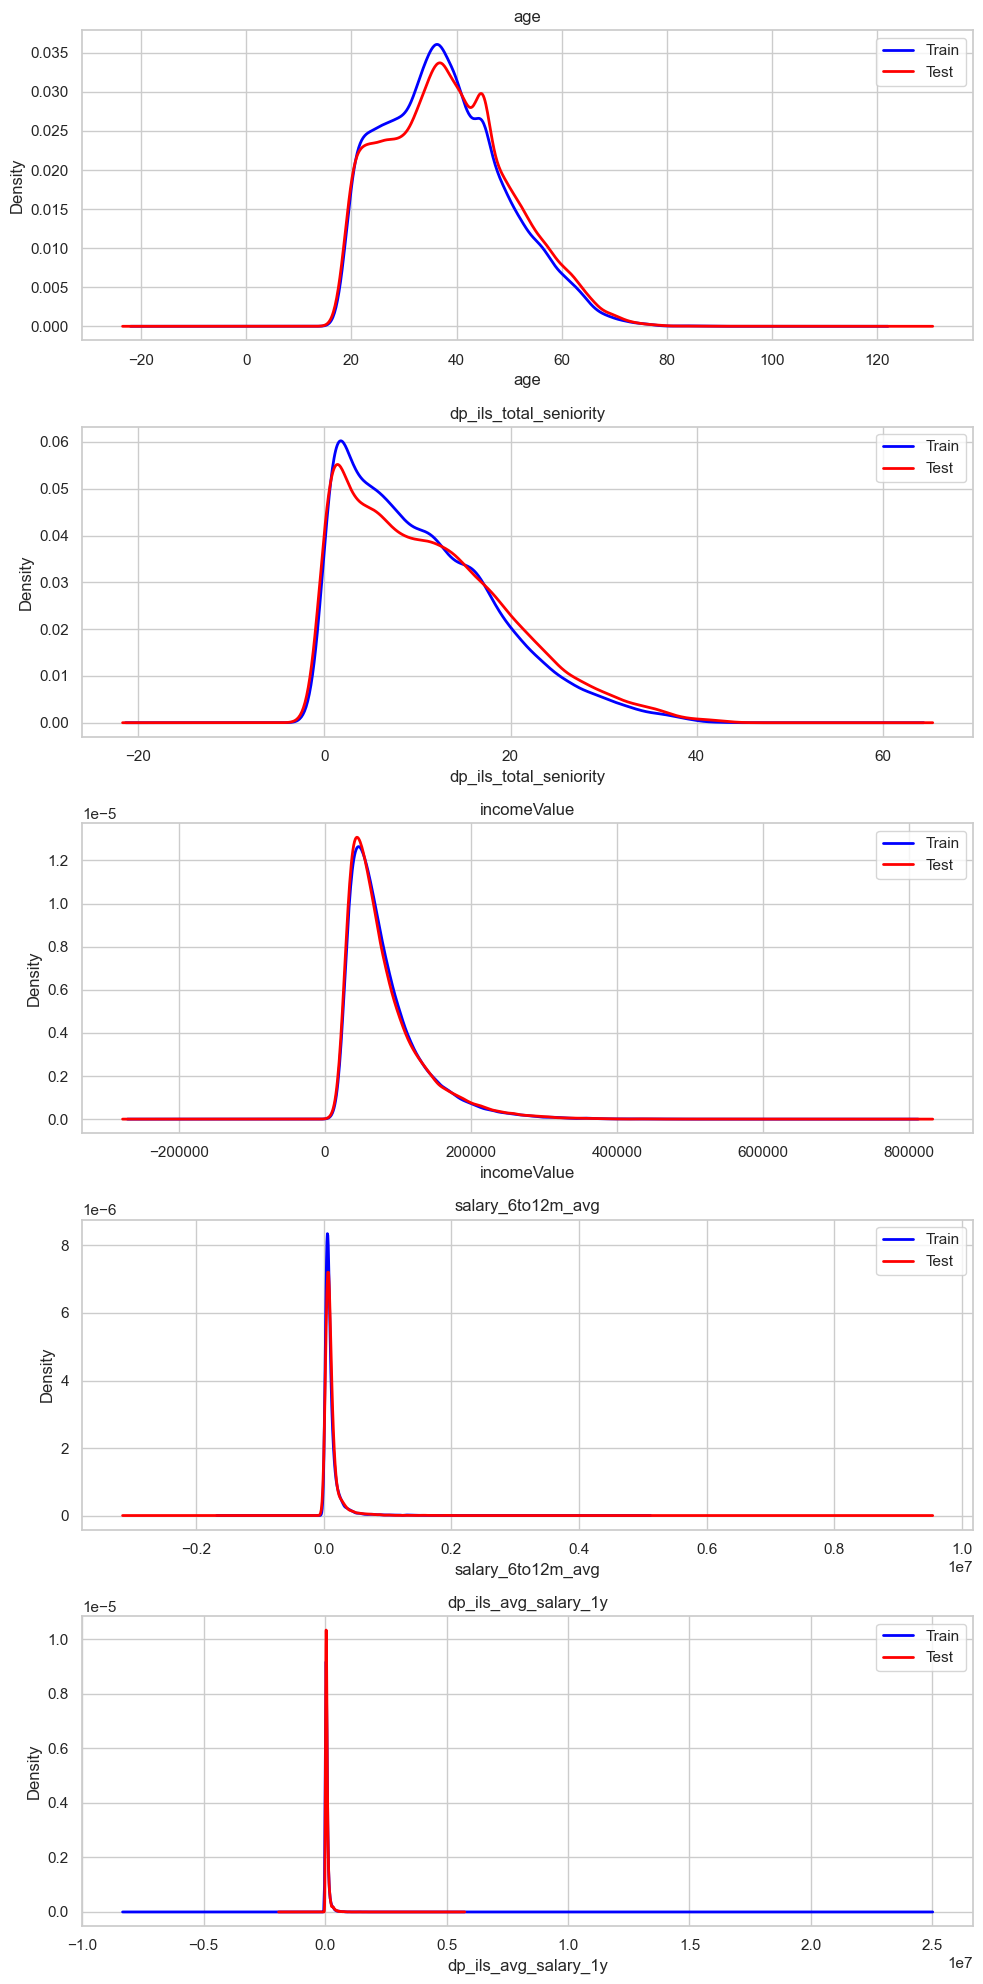

In [55]:
features = ["age", "dp_ils_total_seniority", "incomeValue", "salary_6to12m_avg", "dp_ils_avg_salary_1y"]
fig, axes = plt.subplots(len(features), 1, figsize=(10, 20))
for ax, feature in zip(axes, features):

    train[feature].dropna().plot(kind="kde",ax=ax,color="blue", linewidth=2, label="Train")
    test[feature].dropna().plot(kind="kde", ax=ax, color="red", linewidth=2, label="Test")
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.legend()

plt.tight_layout()
plt.show()

In [13]:
# В целом они по большей части совпадают, но для последнего признака хвост распределения значительно короче в тесте.

In [14]:
cols = train.select_dtypes(include=["int", "int32", "int64", "object"]).columns
nunique = train[cols].nunique().sort_values(ascending=False)
high_cardinality = nunique[nunique > 1000]

print(high_cardinality)

id                                      76786
hdb_bki_active_cc_max_outstand          42497
hdb_bki_total_max_overdue_sum           33000
hdb_bki_other_active_pil_outstanding    31826
hdb_bki_total_pil_max_overdue           29196
hdb_bki_total_pil_max_limit             27641
hdb_bki_total_max_limit                 26616
bki_total_il_max_limit                  25103
bki_total_max_limit                     23846
hdb_bki_active_pil_max_limit            22244
hdb_bki_total_cc_max_overdue            20775
hdb_bki_active_cc_max_overdue           17841
hdb_bki_other_active_ip_outstanding     13905
bki_total_ip_max_outstand               11783
hdb_bki_total_auto_max_limit             8874
hdb_bki_total_ip_max_limit               8491
hdb_bki_total_cc_max_limit               6385
dp_ewb_last_employment_position          6093
hdb_bki_total_micro_max_overdue          5601
hdb_bki_active_cc_max_limit              4481
hdb_bki_total_pil_last_days              4446
hdb_bki_last_product_days         

In [15]:
cat_cols = train.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Количество категориальных признаков: {len(cat_cols)}")
print(cat_cols)

Количество категориальных признаков: 41
['dt', 'hdb_bki_total_max_limit', 'hdb_bki_total_cc_max_limit', 'gender', 'adminarea', 'hdb_bki_total_pil_max_limit', 'hdb_bki_active_cc_max_limit', 'city_smart_name', 'hdb_bki_other_active_pil_outstanding', 'dp_ewb_last_employment_position', 'hdb_bki_total_products', 'hdb_bki_total_max_overdue_sum', 'addrref', 'bki_total_auto_cnt', 'dp_address_unique_regions', 'hdb_bki_total_ip_max_limit', 'hdb_bki_total_cnt', 'bki_total_oth_cnt', 'bki_total_ip_max_outstand', 'hdb_bki_total_ip_cnt', 'hdb_bki_active_cc_max_outstand', 'hdb_bki_total_pil_max_overdue', 'bki_total_il_max_limit', 'bki_total_products', 'bki_active_auto_cnt', 'bki_total_max_limit', 'hdb_bki_total_auto_max_limit', 'hdb_bki_total_micro_max_overdue', 'bki_total_active_products', 'hdb_bki_total_active_products', 'hdb_bki_total_micro_cnt', 'hdb_bki_active_pil_cnt', 'period_last_act_ad', 'hdb_bki_total_cc_max_overdue', 'hdb_bki_total_pil_last_days', 'hdb_bki_active_pil_max_limit', 'hdb_bki_to

In [16]:
global_mean = train["target"].mean()
print(f"Общий средний тагрет: {global_mean:,.2f}")

Общий средний тагрет: 92,648.24


In [17]:
results = []
for col in cat_cols:
    freq = train[col].value_counts(dropna=False)
    rare_categories = freq[freq <= 3].index

    if len(rare_categories) == 0:
        continue
    rare_rows = train[train[col].isin(rare_categories)]
    results.append({
        "feature": col,
        "n_rare_categories": len(rare_categories),
        "n_rows": len(rare_rows),
        "rare_mean_target": rare_rows["target"].mean(),
        "global_mean_target": global_mean,
        "difference": rare_rows["target"].mean() - global_mean
    })
results = pd.DataFrame(results)
results = results.sort_values("difference", key=abs, ascending=False)
display(results)

,feature,n_rare_categories,n_rows,rare_mean_target,global_mean_target,difference
21,bki_total_products,1,1,1.325763e+06,92648.243236,1.233115e+06
15,bki_total_oth_cnt,9,15,3.315614e+05,92648.243236,2.389132e+05
5,city_smart_name,1,1,4.241001e+04,92648.243236,-5.023824e+04
29,hdb_bki_active_pil_cnt,14,19,1.426380e+05,92648.243236,4.998976e+04
30,period_last_act_ad,8,18,1.400274e+05,92648.243236,4.737916e+04
13,hdb_bki_total_ip_max_limit,7892,9026,1.393660e+05,92648.243236,4.671774e+04
24,hdb_bki_total_auto_max_limit,8777,9121,1.373430e+05,92648.243236,4.469480e+04
28,hdb_bki_total_micro_cnt,52,85,1.369261e+05,92648.243236,4.427781e+04
8,hdb_bki_total_products,114,189,1.364984e+05,92648.243236,4.385012e+04
11,bki_total_auto_cnt,4,9,1.343514e+05,92648.243236,4.170319e+04


In [18]:
feature = results.iloc[0]["feature"]

freq = train[feature].value_counts(dropna=False)
rare_categories = freq[freq <= 3].index

display(
    train.loc[
        train[feature].isin(rare_categories),
        [feature, "target"]
    ].sort_values("target")
)

,bki_total_products,target
30920,8.0,1325762.82
